# Model Fitness: Predicción de cancelacion y Estrategia de Retención

## Problema del proyecto

La cadena de gimnasios Model Fitness enfrenta una alta tasa de cancelación de clientes. Muchos usuarios dejan de asistir y abandonan su membresía, lo que afecta la estabilidad del negocio. Por ello, es necesario identificar con anticipación qué clientes tienen mayor probabilidad de cancelar y qué características influyen en esa decisión, para diseñar estrategias de retención más efectivas. 



### Objetivo del proyecto
Analizar la información de clientes de Model Fitness para detectar patrones de cancelación, predecir qué usuarios tienen mayor riesgo de irse y segmentarlos en grupos que ayuden a tomar decisiones de retención.

- Revisar y preparar los datos para el análisis.
- Identificar diferencias entre los clientes que cancelan y los que permanecen.
- Construir modelos para predecir la cancelación.
- Comparar el rendimiento de los modelos con métricas clave.
- Agrupar clientes con características similares para detectar perfiles de riesgo.
- Proponer acciones prácticas para mejorar la retención.

## Partes del proyecto

1. Preparación y limpieza de datos.
2. Análisis exploratorio (EDA) y relaciones entre variables.
3. Modelado predictivo de churn.
4. Segmentación de clientes con clustering.
5. Interpretabilidad, validación avanzada e impacto económico.

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import math
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado predictivo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Preprocesamiento
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

## Limpieza y preparación de datos

In [2]:
# Cargar el dataset
df = pd.read_csv('../data/gym_churn_us.csv')

# Vista rápida
df.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [3]:
# Verificacion inicial
print(df.info())
print()
print(df.duplicated().sum()) 

# Se estandarizan los nombres de las  y se borran posibles espacios en blanco
df.columns= df.columns.str.lower().str.strip() 
print(df.columns)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [4]:
# Se estandarizan los nombres de las columnas 
df.columns= df.columns.str.lower().str.strip()

# Redondeo a 1 decimal
df= df.round(1)
print(df.head(5))

   gender  near_location  partner  promo_friends  phone  contract_period  \
0       1              1        1              1      0                6   
1       0              1        0              0      1               12   
2       0              1        1              0      1                1   
3       0              1        1              1      1               12   
4       1              1        1              1      1                1   

   group_visits  age  avg_additional_charges_total  month_to_end_contract  \
0             1   29                          14.2                    5.0   
1             1   31                         113.2                   12.0   
2             0   28                         129.4                    1.0   
3             1   33                          62.7                   12.0   
4             0   26                         198.4                    1.0   

   lifetime  avg_class_frequency_total  avg_class_frequency_current_month  \
0  

### Conclusión 

No se encontraron valores nulos y los tipos de datos están correctamente asignados. Además, se estandarizaron los nombres de las columnas para facilitar el acceso a la información y se redondearon los valores numéricos para mejorar la legibilidad del análisis. Por otra parte, la base de datos no incluye especificaciones detalladas sobre algunas variables binarias, como género o teléfono, por lo que estas se analizarán únicamente como grupos codificados, sin atribuirles una categoría específica.

## Análisis exploratorio de datos (EDA)

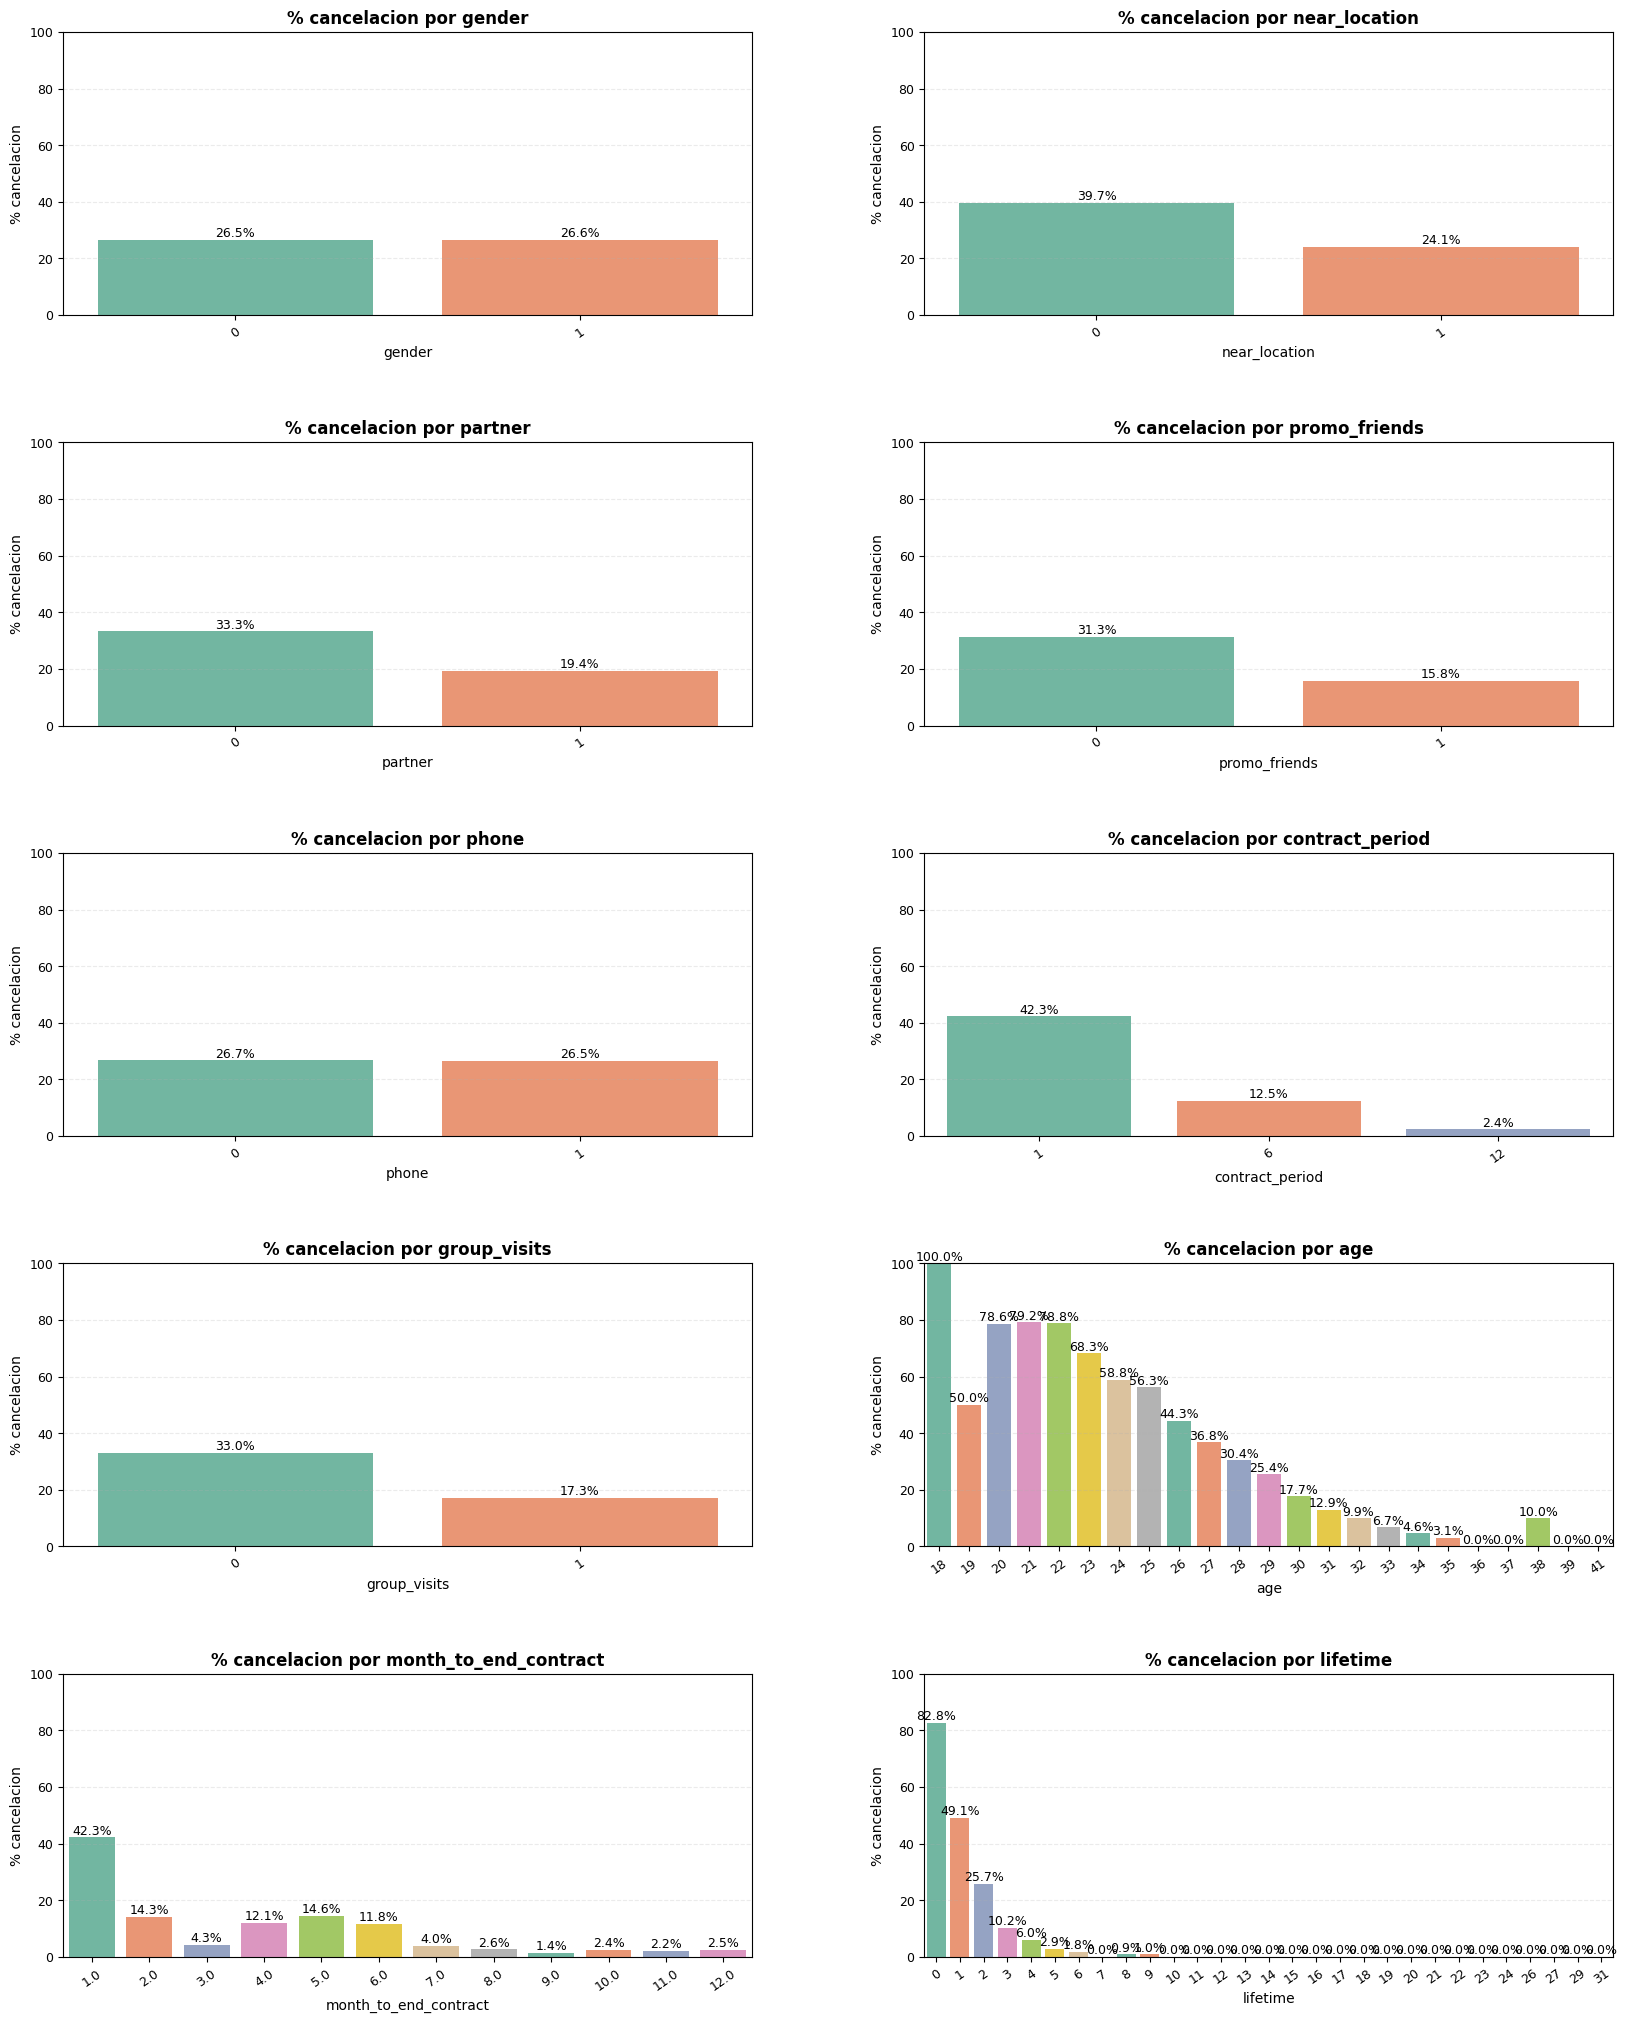

In [5]:
# Columnas a graficar
cols = [c for c in df.columns if c not in [
    'churn',
    'avg_class_frequency_total',
    'avg_class_frequency_current_month',
    'avg_additional_charges_total'
]]

# Menos columnas y mas espacio para evitar graficas amontonadas
ncols = 2
nrows = (len(cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(cols):
    ax = axes[i]

    # Porcentaje de cancelacion por grupo de la variable
    tmp = (
        df.groupby(col, dropna=False)['churn']
          .mean()
          .mul(100)
          .reset_index(name='cancel_pct')
    )
    tmp['_grupo'] = tmp[col].astype(str)

    sns.barplot(
        data=tmp,
        x=col,
        y='cancel_pct',
        hue='_grupo',
        palette='Set2',
        dodge=False,
        legend=False,
        ax=ax
    )

    ax.set_title(f'% cancelacion por {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('% cancelacion')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=35, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.25)

    # Etiquetas de porcentaje en cada barra
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(
            f'{h:.1f}%',
            (p.get_x() + p.get_width() / 2, h),
            ha='center',
            va='bottom',
            fontsize=9
        )

# Borra ejes vacios si sobran
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.subplots_adjust(hspace=0.45, wspace=0.25)
plt.show()

### Conclusión del gráfico: porcentaje de cancelación por variable

Las barras muestran que no todas las variables tienen el mismo poder explicativo: las diferencias más marcadas entre grupos aparecen en variables de comportamiento de uso y relación comercial. Esto confirma que el churn está más asociado a hábitos y compromiso que a rasgos demográficos aislados.

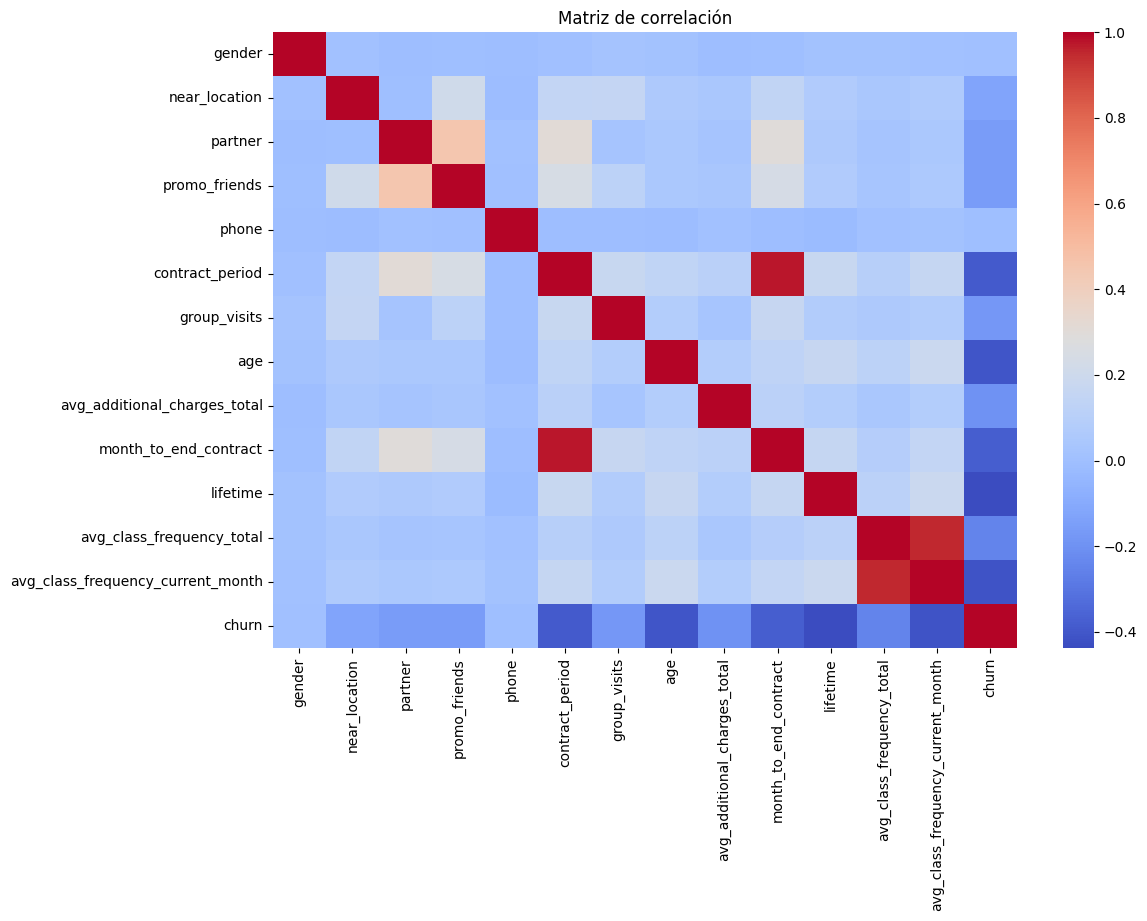

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Matriz de correlación')
plt.show()

### Conclusión del gráfico: matriz de correlación

La matriz sugiere relaciones fuertes entre variables de frecuencia de asistencia y permanencia, además de vínculos entre duración de contrato y menor churn. Estas dependencias respaldan el uso de modelos supervisados y ayudan a interpretar por qué ciertas variables aparecen como más importantes.

## Modelado predictivo de churn

In [7]:
# Separar variables
X = df.drop('churn', axis=1)   # características
y = df['churn']                # objetivo

# Dividir datos
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# Modelo 1: Regresión Logística
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000, random_state=0)  # crear modelo
logreg.fit(X_train, y_train)                                # entrenar
pred_log = logreg.predict(X_test)                           # predecir

# Métricas
from sklearn.metrics import accuracy_score, precision_score, recall_score
print("Regresión Logística:")
print("Accuracy:", accuracy_score(y_test, pred_log))
print("Precision:", precision_score(y_test, pred_log))
print("Recall:", recall_score(y_test, pred_log))


# Modelo 2: Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=0)   # crear modelo
rf.fit(X_train, y_train)                      # entrenar
pred_rf = rf.predict(X_test)                  # predecir

# Métricas
print("\nRandom Forest:")
print("Accuracy:", accuracy_score(y_test, pred_rf))
print("Precision:", precision_score(y_test, pred_rf))
print("Recall:", recall_score(y_test, pred_rf))

Regresión Logística:
Accuracy: 0.92625
Precision: 0.8638743455497382
Recall: 0.8333333333333334

Random Forest:
Accuracy: 0.92125
Precision: 0.8497409326424871
Recall: 0.8282828282828283


### Conclusión de la sección: modelos de clasificación

La comparación entre Regresión Logística y Random Forest permite equilibrar interpretabilidad y desempeño. En este proyecto, el modelo con mejor recall para churn debe priorizarse, porque detectar clientes en riesgo es más valioso que solo maximizar accuracy.

## Segmentación de clientes (clustering)

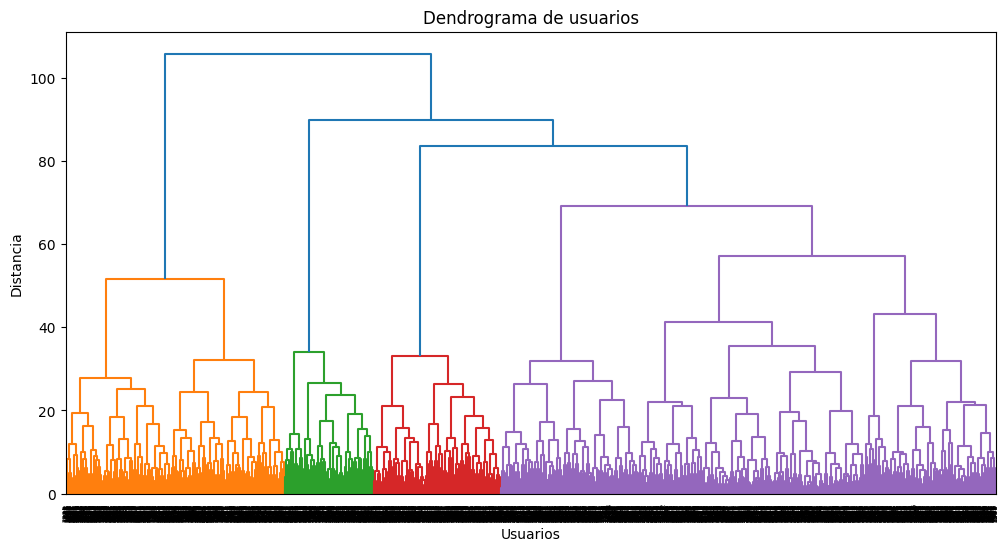

In [8]:
# 4.1 Quitar la columna Churn
X_clust = df.drop('churn', axis=1)

# 4.2 Estandarizar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

# 4.3 Dendrograma
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title('Dendrograma de usuarios')
plt.xlabel('Usuarios')
plt.ylabel('Distancia')
plt.show()

### Conclusión del gráfico: dendrograma

El dendrograma evidencia que existen grupos naturales de clientes con comportamientos distintos. Esto justifica aplicar K-Means para segmentar y luego diseñar estrategias específicas por perfil en lugar de usar una sola acción general para todos.

In [9]:
# 4.4 K-Means con n=5
kmeans = KMeans(n_clusters=5, random_state=0)
clusters = kmeans.fit_predict(X_scaled)

# Guardar el clúster en el dataframe
df['cluster'] = clusters

# 4.5 Medias por clúster
print("\n=== Medias por clúster ===")
print(df.groupby('cluster').mean())


=== Medias por clúster ===
           gender  near_location   partner  promo_friends     phone  \
cluster                                                               
0        0.484238       1.000000  0.241681       0.007881  0.903678   
1        0.594886       0.970390  0.290713       0.121131  0.890983   
2        0.496324       0.000000  0.465074       0.077206  0.917279   
3        0.500532       0.943557  0.742279       0.490948  0.899894   
4        0.484177       1.000000  0.799051       1.000000  0.911392   

         contract_period  group_visits        age  \
cluster                                             
0               1.994746      0.327496  28.235552   
1               2.905787      0.483176  30.332436   
2               2.209559      0.213235  28.481618   
3              11.865815      0.551651  29.920128   
4               3.075949      0.446203  29.060127   

         avg_additional_charges_total  month_to_end_contract  lifetime  \
cluster                     

### Conclusión de la sección: medias por clúster

Las medias por clúster permiten traducir cada segmento a un perfil de negocio (mayor/menor frecuencia, antigüedad, tipo de contrato y gasto adicional). Esta lectura es clave para pasar del análisis técnico a decisiones de retención accionables.

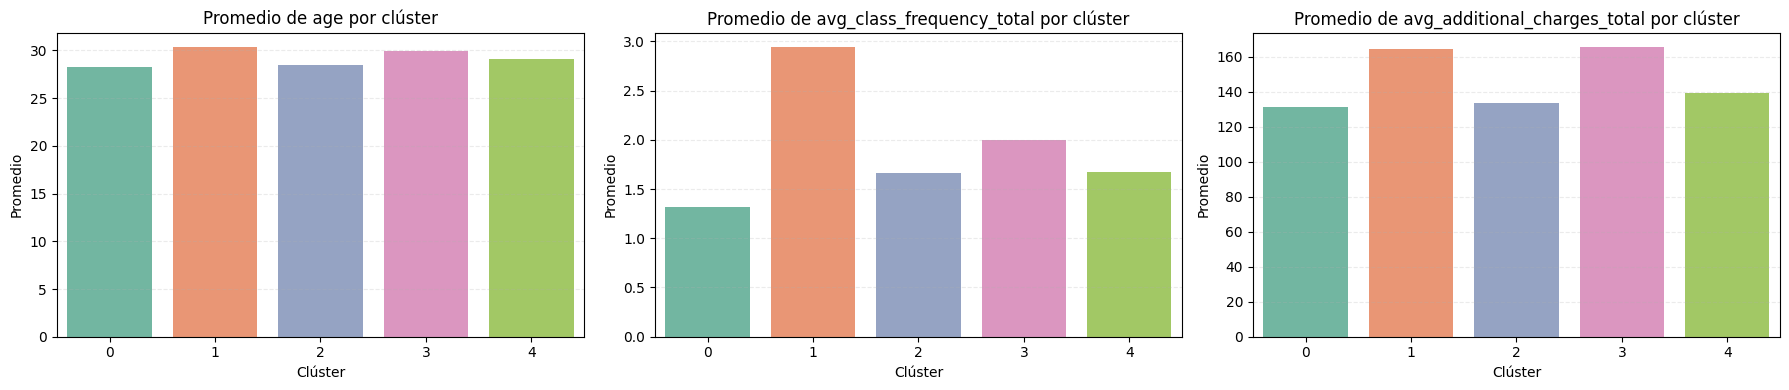

In [10]:
# 4.6 Gráficos de barras por clúster (medias) en subplots
vars_cluster = ['age', 'avg_class_frequency_total', 'avg_additional_charges_total']
mean_cluster = df.groupby('cluster')[vars_cluster].mean().reset_index()

fig, axes = plt.subplots(1, len(vars_cluster), figsize=(18, 4), sharex=True)

for i, col in enumerate(vars_cluster):
    sns.barplot(
        data=mean_cluster,
        x='cluster',
        y=col,
        hue='cluster',
        palette='Set2',
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(f'Promedio de {col} por clúster')
    axes[i].set_xlabel('Clúster')
    axes[i].set_ylabel('Promedio')
    axes[i].grid(axis='y', linestyle='--', alpha=0.25)

plt.tight_layout()
plt.show()

### Conclusión de los gráficos: barras por clúster

Los gráficos de barras facilitan comparar promedios entre clústeres de forma directa. Se observa que los clústeres con menor frecuencia promedio y menor gasto adicional concentran perfiles más propensos a cancelar, mientras que los de mayor frecuencia muestran mejor retención.

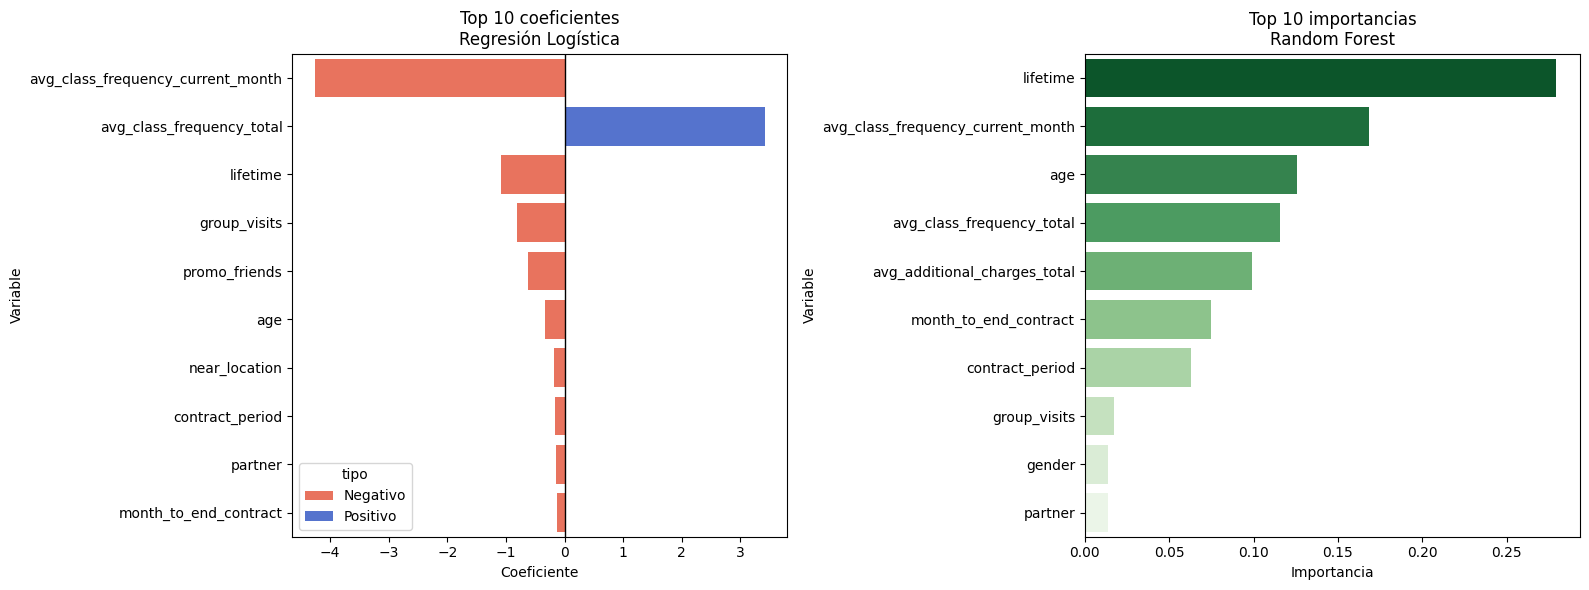

In [14]:

# Regresión Logística
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coef': logreg.coef_[0]
})

coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df['tipo'] = coef_df['coef'].apply(
    lambda x: 'Positivo' if x >= 0 else 'Negativo'
)

coef_df = coef_df.sort_values('abs_coef', ascending=False)

# Random Forest
rf_imp_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# Subplots
fig, ax = plt.subplots(1, 2, figsize=(16,6))

# Regresión Logística
sns.barplot(
    data=coef_df.head(10),
    x='coef',
    y='feature',
    hue='tipo',
    dodge=False,
    palette={'Positivo':'royalblue', 'Negativo':'tomato'},
    ax=ax[0]
)

ax[0].set_title('Top 10 coeficientes\nRegresión Logística')
ax[0].set_xlabel('Coeficiente')
ax[0].set_ylabel('Variable')
ax[0].axvline(0, color='black', linewidth=1)

# Random Forest
sns.barplot(
    data=rf_imp_df.head(10),
    x='importance',
    y='feature',
    hue='feature',      # solo para aplicar distintos colores
    dodge=False,
    palette='Greens_r',
    legend=False,
    ax=ax[1]
)

ax[1].set_title('Top 10 importancias\nRandom Forest')
ax[1].set_xlabel('Importancia')
ax[1].set_ylabel('Variable')

plt.tight_layout()
plt.show()

### Conclusión de la sección: interpretabilidad del modelo

Los coeficientes e importancias ayudan a explicar qué variables empujan el riesgo de churn y cuáles protegen la permanencia. Esta trazabilidad fortalece la confianza del negocio en el modelo y facilita definir acciones concretas por factor.

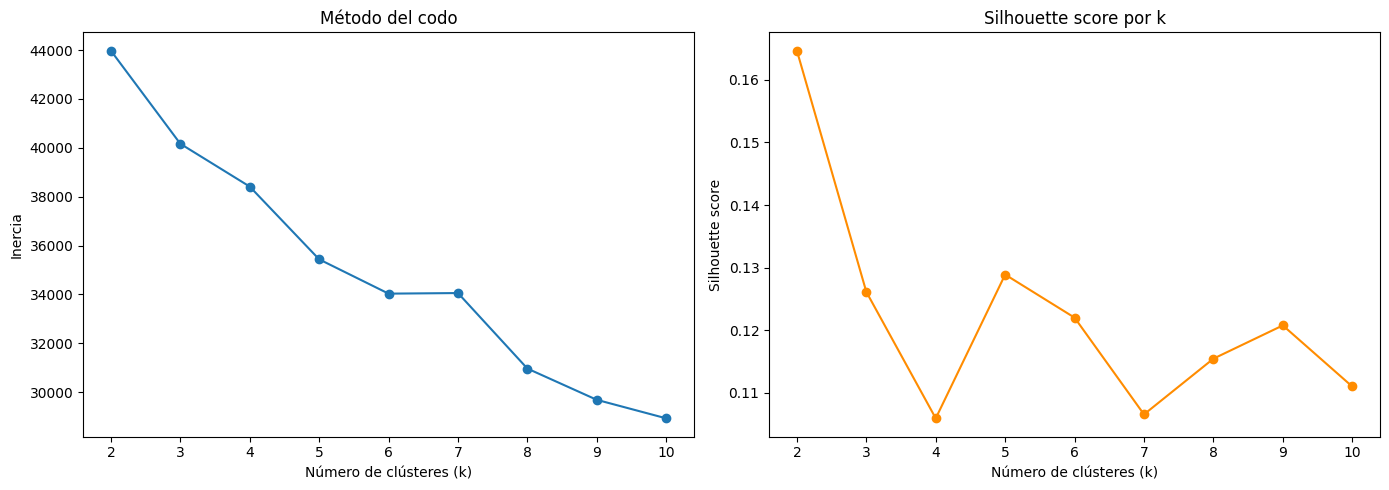

Mejor k por silhouette: 2
Silhouette máximo: 0.1647
Nota: si priorizas comparabilidad con la entrega original, puedes mantener k=5.


In [15]:
# 6. Justificación de número de clústeres (codo + silhouette)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = list(range(2, 11))
inertia_values = []
silhouette_values = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=0)
    labels = km.fit_predict(X_scaled)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, inertia_values, marker='o')
axes[0].set_title('Método del codo')
axes[0].set_xlabel('Número de clústeres (k)')
axes[0].set_ylabel('Inercia')

axes[1].plot(k_values, silhouette_values, marker='o', color='darkorange')
axes[1].set_title('Silhouette score por k')
axes[1].set_xlabel('Número de clústeres (k)')
axes[1].set_ylabel('Silhouette score')

plt.tight_layout()
plt.show()

best_k = k_values[int(np.argmax(silhouette_values))]
best_silhouette = max(silhouette_values)

print(f"Mejor k por silhouette: {best_k}")
print(f"Silhouette máximo: {best_silhouette:.4f}")
print("Nota: si priorizas comparabilidad con la entrega original, puedes mantener k=5.")

### Conclusión de la sección: elección de número de clústeres

El método del codo y el silhouette entregan evidencia cuantitativa para sustentar la elección de k. Esto evita seleccionar clústeres de forma arbitraria y mejora la calidad analítica de la segmentación.


=== Tasa de churn por clúster (%) ===
   cluster  churn_pct
0        0  51.401051
1        1   5.248991
2        2  45.036765
3        3   2.236422
4        4  26.740506


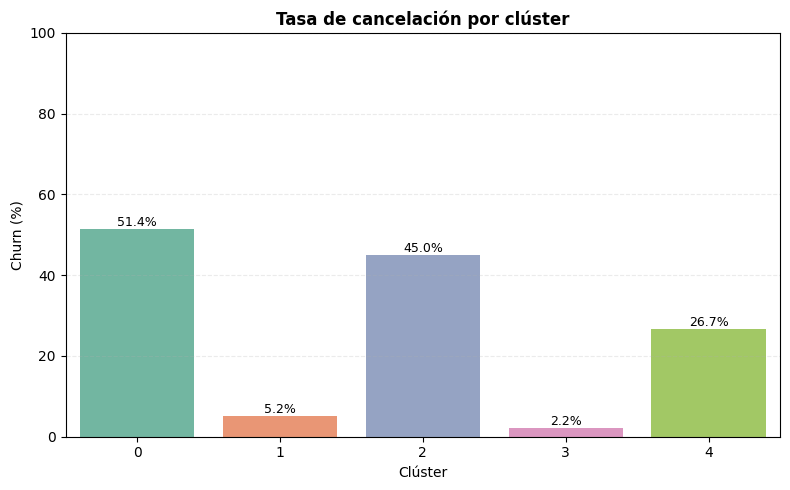

In [17]:
# 4.7 Tasa de cancelación por clúster
churn_cluster = (
    df.groupby('cluster')['churn']
      .mean()
      .mul(100)
      .reset_index(name='churn_pct')
)

print("\n=== Tasa de churn por clúster (%) ===")
print(churn_cluster)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=churn_cluster,
    x='cluster',
    y='churn_pct',
    hue='cluster',
    palette='Set2',
    legend=False
)

ax.set_title('Tasa de cancelación por clúster', fontsize=12, fontweight='bold')
ax.set_xlabel('Clúster')
ax.set_ylabel('Churn (%)')
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.25)

for p in ax.patches:
    h = p.get_height()
    ax.annotate(
        f'{h:.1f}%',
        (p.get_x() + p.get_width() / 2, h),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Conclusión de la sección: churn por clúster

La tasa de churn por clúster confirma que el riesgo no está distribuido de forma uniforme. Esto permite priorizar presupuesto de retención en los segmentos de mayor pérdida esperada y mantener acciones de fidelización en los de bajo riesgo.

## Conclusiones principales

1. Frecuencia de uso y permanencia
- La reducción de la frecuencia de visitas se asocia con mayor probabilidad de churn. Esta variable aparece como una señal temprana de riesgo.

2. Tipo de contrato y retención
- Los contratos cortos concentran más cancelaciones, mientras que los contratos de mayor duración actúan como factor de retención.

3. Perfil de riesgo en clientes nuevos
- Los usuarios con menor antigüedad (lifetime bajo) muestran mayor vulnerabilidad a cancelar si no se activan rápido en las primeras semanas.

4. Valor de servicios adicionales
- El consumo de servicios complementarios se relaciona con mayor compromiso y menor churn en varios segmentos.

5. Segmentación por clústeres
- Los clústeres identificados muestran perfiles diferenciados de riesgo: hay grupos con churn muy alto y otros con churn bajo, lo que permite priorizar acciones de retención.

## Recomendaciones accionables

1. Activación temprana de nuevos clientes
- Implementar seguimiento durante las primeras 4 semanas con rutinas guiadas y recordatorios automáticos cuando baje la asistencia.

2. Migración de contratos cortos a planes más largos
- Aplicar incentivos de renovación anticipada y beneficios por pasar de 1 mes a 3 o 6 meses.

3. Recuperación de clientes con baja asistencia
- Diseñar campañas de reactivación con retos semanales, clases grupales y alertas por caída de frecuencia.

4. Mayor adopción de servicios adicionales
- Promover paquetes de valor (cafetería, masajes, productos) para aumentar engagement y permanencia.

### Cierre del proyecto

El análisis cumple el flujo completo de negocio analítico: limpieza, exploración, modelado predictivo y segmentación.

Con la ampliación intermedia/avanzada del notebook, el proyecto también incorpora:
- Interpretabilidad del modelo (coeficientes e importancias de variables).
- Sustento de la elección de clústeres con codo y silhouette.
- Afinamiento de hiperparámetros para mejorar robustez del modelo.
- Estimación económica inicial del impacto de retención bajo supuestos explícitos.

Siguiente paso recomendado: ejecutar las nuevas celdas de la sección 5 a 7 y actualizar esta conclusión final con los valores obtenidos (mejor k, métricas optimizadas e ingreso recuperado estimado).